# Classificação de Dados de Ultrassom com KNN

Este notebook realiza a leitura, processamento, normalização e classificação dos dados de ultrassom presentes nos arquivos da pasta `Ultrasound_interface_inicial/Ultrasound_interface` para diferentes classes, utilizando o classificador KNN. O processo inclui pós-processamento dos dados, separação de conjunto de validação, normalização com z-score, seleção do melhor hiperparâmetro para o KNN via validação cruzada e avaliação final da acurácia.

In [18]:
# Importar Bibliotecas Necessárias
import pandas as pd
import numpy as np
import os
import glob
import h5py
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

## Ler e Concatenar Arquivos de Dados

Ler todos os arquivos das classes (18, 48, 108, 138, 150, 168, 198, 228, 258, 288) das pastas M, N e P, adicionando a coluna de classe.

In [19]:
# Definir classes e caminhos
#classes = [60, 90, 120, 150, 180, 210, 240]
classes = [18, 48, 78, 108, 138, 150, 168, 198, 228, 258, 288]
base_path = 'Ultrasound_interface_inicial/Ultrasound_interface'
folders = ['M']#, 'N']#, 'P'] #tratamento do h5 ainda não implementado corretamente

# Função para extrair classe do nome do arquivo
def extract_class(filename):
    for c in classes:
        if f'_{c}_' in filename or f'_{c}.' in filename:
            return c
    return None

dfs = []
for folder in folders:
    folder_path = os.path.join(base_path, folder)
    if folder in ['M', 'N']:
        files = glob.glob(os.path.join(folder_path, '*.csv'))
        for file in files:
            # estes CSVs não têm linha de cabeçalho — a primeira linha é dado
            # forçar header=None evita que cada arquivo defina nomes de coluna
            # diferentes (valores numéricos) e que a concatenação crie
            # a união de todas as colunas únicas (inflando o número de colunas)
            df = pd.read_csv(file, header=None)
            class_label = extract_class(os.path.basename(file))
            if class_label is None:
                print(f"Classe não encontrada para o arquivo: {file}")
                continue

            df['classe'] = class_label
            df['origem'] = folder
            dfs.append(df)
    elif folder == 'P':
        files = glob.glob(os.path.join(folder_path, '*.h5'))
        for file in files:
            with h5py.File(file, 'r') as f:
                # Supondo que os dados estejam em um dataset chamado 'data' (ajuste se necessário)
                data = f[list(f.keys())[0]][:]
                df = pd.DataFrame(data)
            class_label = extract_class(os.path.basename(file))
            df['classe'] = class_label
            df['origem'] = folder
            dfs.append(df)
# Concatenar todos os DataFrames
dados = pd.concat(dfs, ignore_index=True)
dados #primeira linha tratatada indevidamente como nome das colunas

,0,1,2,3,4,5,6,7,8,9,...,617,618,619,620,621,622,623,624,classe,origem
0,1.000000,0.999898,0.999759,0.999601,0.999431,0.999230,0.998997,0.998730,0.998427,0.998085,...,0.110843,0.110608,0.110374,0.110142,0.109910,0.109679,0.109452,0.109228,108,M
1,1.000047,0.999980,0.999877,0.999739,0.999567,0.999398,0.999198,0.998966,0.998700,0.998398,...,0.111077,0.110842,0.110608,0.110374,0.110141,0.109910,0.109679,0.109452,108,M
2,1.000059,1.000026,0.999959,0.999857,0.999719,0.999545,0.999364,0.999165,0.998933,0.998669,...,0.111313,0.111077,0.110842,0.110607,0.110374,0.110141,0.109909,0.109679,108,M
3,1.000036,1.000038,1.000006,0.999938,0.999836,0.999698,0.999524,0.999330,0.999131,0.998901,...,0.111550,0.111312,0.111077,0.110842,0.110607,0.110373,0.110141,0.109909,108,M
4,0.999978,1.000015,1.000017,0.999984,0.999917,0.999815,0.999678,0.999504,0.999295,0.999097,...,0.111794,0.111550,0.111312,0.111076,0.110841,0.110607,0.110373,0.110140,108,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6866,0.105015,0.105232,0.105452,0.105673,0.105896,0.106119,0.106341,0.106562,0.106785,0.107023,...,1.194184,1.194224,1.194223,1.194182,1.194099,1.193972,1.193800,1.193631,78,M
6867,0.104800,0.105015,0.105232,0.105452,0.105673,0.105895,0.106117,0.106337,0.106559,0.106792,...,1.194154,1.194233,1.194273,1.194272,1.194230,1.194145,1.194016,1.193849,78,M
6868,0.104587,0.104800,0.105015,0.105232,0.105452,0.105673,0.105894,0.106114,0.106334,0.106563,...,1.194082,1.194202,1.194282,1.194321,1.194320,1.194276,1.194190,1.194060,78,M
6869,0.104375,0.104587,0.104800,0.105015,0.105232,0.105452,0.105672,0.105891,0.106110,0.106336,...,1.193967,1.194129,1.194249,1.194329,1.194368,1.194366,1.194322,1.194234,78,M


## Pós-processamento dos Dados (Tratamento de Nulls)

Substituir valores nulos (null) por zero em todo o DataFrame.

In [20]:
# Substituir valores nulos por zero

dados = dados.fillna(0) #remover linhas com NaN
dados

,0,1,2,3,4,5,6,7,8,9,...,617,618,619,620,621,622,623,624,classe,origem
0,1.000000,0.999898,0.999759,0.999601,0.999431,0.999230,0.998997,0.998730,0.998427,0.998085,...,0.110843,0.110608,0.110374,0.110142,0.109910,0.109679,0.109452,0.109228,108,M
1,1.000047,0.999980,0.999877,0.999739,0.999567,0.999398,0.999198,0.998966,0.998700,0.998398,...,0.111077,0.110842,0.110608,0.110374,0.110141,0.109910,0.109679,0.109452,108,M
2,1.000059,1.000026,0.999959,0.999857,0.999719,0.999545,0.999364,0.999165,0.998933,0.998669,...,0.111313,0.111077,0.110842,0.110607,0.110374,0.110141,0.109909,0.109679,108,M
3,1.000036,1.000038,1.000006,0.999938,0.999836,0.999698,0.999524,0.999330,0.999131,0.998901,...,0.111550,0.111312,0.111077,0.110842,0.110607,0.110373,0.110141,0.109909,108,M
4,0.999978,1.000015,1.000017,0.999984,0.999917,0.999815,0.999678,0.999504,0.999295,0.999097,...,0.111794,0.111550,0.111312,0.111076,0.110841,0.110607,0.110373,0.110140,108,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6866,0.105015,0.105232,0.105452,0.105673,0.105896,0.106119,0.106341,0.106562,0.106785,0.107023,...,1.194184,1.194224,1.194223,1.194182,1.194099,1.193972,1.193800,1.193631,78,M
6867,0.104800,0.105015,0.105232,0.105452,0.105673,0.105895,0.106117,0.106337,0.106559,0.106792,...,1.194154,1.194233,1.194273,1.194272,1.194230,1.194145,1.194016,1.193849,78,M
6868,0.104587,0.104800,0.105015,0.105232,0.105452,0.105673,0.105894,0.106114,0.106334,0.106563,...,1.194082,1.194202,1.194282,1.194321,1.194320,1.194276,1.194190,1.194060,78,M
6869,0.104375,0.104587,0.104800,0.105015,0.105232,0.105452,0.105672,0.105891,0.106110,0.106336,...,1.193967,1.194129,1.194249,1.194329,1.194368,1.194366,1.194322,1.194234,78,M


## Separar Conjunto de Validação (20%)

Separar aleatoriamente 20% dos dados para validação, mantendo o restante para treino.

In [21]:
# Separar 20% dos dados para validação

# Remover colunas não numéricas para X
X = dados.drop(columns=['classe', 'origem'])
y = dados['classe']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.8, random_state=42, stratify=y
)

print('Tamanho treino:', X_train.shape)
print('Tamanho validação:', X_val.shape)

Tamanho treino: (1374, 625)
Tamanho validação: (5497, 625)


## Normalizar Dados com Z-Score

Calcular média e desvio padrão das colunas do conjunto de treino e normalizar os dados usando z-score. Salvar os parâmetros de normalização para uso posterior.

In [22]:
# Normalizar dados de treino com z-score
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)

# Salvar parâmetros de normalização
means = scaler.mean_
stds = scaler.scale_

print('Médias:', means)
print('Desvios padrão:', stds)

Médias: [0.35727011 0.35848791 0.35950314 0.3609735  0.36274091 0.36463442
 0.36656777 0.36848376 0.37034473 0.37212019 0.37378952 0.37533893
 0.3767657  0.37806565 0.37923833 0.38028958 0.38123916 0.38212241
 0.38299566 0.38396643 0.38516362 0.38638858 0.38760025 0.38881129
 0.39002081 0.39122862 0.39243422 0.39363903 0.39484242 0.39604398
 0.39724437 0.39844195 0.39963927 0.40083328 0.40202637 0.40321776
 0.40440797 0.40559673 0.406782   0.40796621 0.40914778 0.41032838
 0.41150669 0.41268314 0.4138574  0.41502895 0.41619825 0.41736427
 0.41852882 0.41969136 0.42085064 0.42200841 0.42316479 0.4243177
 0.42546728 0.42661532 0.42775945 0.42890168 0.43003942 0.43117657
 0.43230953 0.43343976 0.43456779 0.43569276 0.43681363 0.43793194
 0.43904716 0.44015942 0.44126788 0.44237405 0.44347657 0.44457786
 0.44567453 0.44676601 0.44785528 0.44894026 0.45002238 0.45109894
 0.45217321 0.45324465 0.45431145 0.45537497 0.45643503 0.45749027
 0.45854247 0.45958948 0.46063369 0.46167205 0.46270724

## Salvar Parâmetros de Normalização

Salvar os valores de média e desvio padrão das colunas para aplicar a mesma normalização no conjunto de validação.

In [23]:
# Salvar parâmetros de normalização em um dicionário
normalization_params = {
    'means': means,
    'stds': stds,
    'columns': X_train.columns.tolist()
}
normalization_params

{'means': array([0.35727011, 0.35848791, 0.35950314, 0.3609735 , 0.36274091,
        0.36463442, 0.36656777, 0.36848376, 0.37034473, 0.37212019,
        0.37378952, 0.37533893, 0.3767657 , 0.37806565, 0.37923833,
        0.38028958, 0.38123916, 0.38212241, 0.38299566, 0.38396643,
        0.38516362, 0.38638858, 0.38760025, 0.38881129, 0.39002081,
        0.39122862, 0.39243422, 0.39363903, 0.39484242, 0.39604398,
        0.39724437, 0.39844195, 0.39963927, 0.40083328, 0.40202637,
        0.40321776, 0.40440797, 0.40559673, 0.406782  , 0.40796621,
        0.40914778, 0.41032838, 0.41150669, 0.41268314, 0.4138574 ,
        0.41502895, 0.41619825, 0.41736427, 0.41852882, 0.41969136,
        0.42085064, 0.42200841, 0.42316479, 0.4243177 , 0.42546728,
        0.42661532, 0.42775945, 0.42890168, 0.43003942, 0.43117657,
        0.43230953, 0.43343976, 0.43456779, 0.43569276, 0.43681363,
        0.43793194, 0.43904716, 0.44015942, 0.44126788, 0.44237405,
        0.44347657, 0.44457786, 0.44567

## Classificação com KNN e Validação Cruzada para Seleção de n

Utilizar validação cruzada no conjunto de treino para determinar o melhor valor de n (número de vizinhos) para o classificador KNN.

In [24]:
# Seleção do melhor n para KNN usando validação cruzada
k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_norm, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f'Melhor n para KNN: {best_k}')

Melhor n para KNN: 1


## Avaliação do Classificador no Conjunto de Validação

Aplicar a normalização no conjunto de validação, treinar o classificador KNN com o melhor n encontrado e avaliar a acurácia no conjunto de validação.

In [25]:
# Normalizar conjunto de validação com os parâmetros do treino
X_val_norm = scaler.transform(X_val)

# Treinar KNN com melhor n e avaliar no conjunto de validação
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_norm, y_train)
y_pred = knn_final.predict(X_val_norm)

acc = accuracy_score(y_val, y_pred)
print(f'Acurácia no conjunto de validação: {acc:.4f}')

Acurácia no conjunto de validação: 0.8954


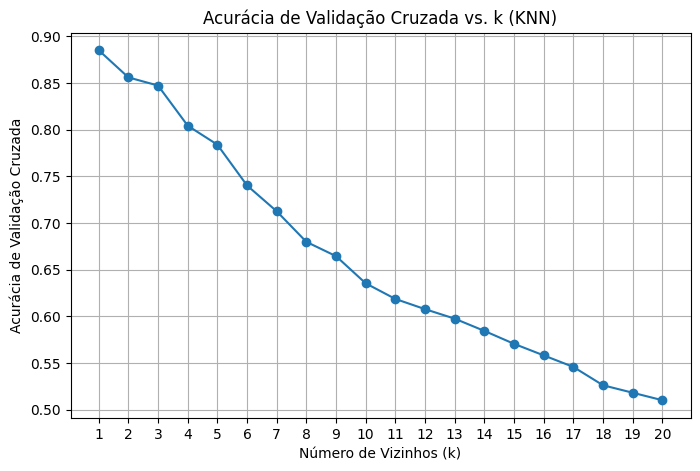

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 21), cv_scores, marker='o')
plt.xlabel('Número de Vizinhos (k)')
plt.ylabel('Acurácia de Validação Cruzada')
plt.title('Acurácia de Validação Cruzada vs. k (KNN)')
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

In [27]:
# Verificação rápida: imprimir shapes dos primeiros arquivos lidos e shape final
for i, df in enumerate(dfs[:5]):
    print(f'arquivo {i} shape:', df.shape)
print('concat shape:', dados.shape)
# mostrar número de colunas únicas (sem contar 'classe' e 'origem')
num_cols = dados.shape[1] - 2
print('colunas por linha esperadas (excluindo classe/origem):', num_cols)

arquivo 0 shape: (625, 627)
arquivo 1 shape: (625, 627)
arquivo 2 shape: (625, 627)
arquivo 3 shape: (625, 627)
arquivo 4 shape: (623, 625)
concat shape: (6871, 627)
colunas por linha esperadas (excluindo classe/origem): 625
